# Statistics Exercises Part 1

This is the first of several exercise pages on statistical programming prepared for use in the course **ITSE 1302** at Austin Community College.

These exercise pages provide a variety of statistical programming examples and were prepared using Jupyter Notebook. They will be delivered to students as HTML files. Students in this course are not expected to know how to create Jupyter Notebooks, but will learn how to use that tool in a subsequent course.

In order to make it possible to copy the code for the examples into a Python script and run them under the stand-alone Python interpreter, most of the code in these exercise pages was written in such a way that it can stand alone and run independently of any code that was written earlier in the notebook.

Many of the exercises use the matplotlib library for generating graphs and histograms. Most of the code was written to run properly without access to advanced libraries such as numpy, scipy, and pandas. (Students will learn about those libraries later.) However, there are a few situations where resources from the numpy library were used to simplify the code. Those resources will be fully explained the first time they are used.

To extract a section of code from the Jupyter notebook format and run it under the Python interpreter,

- Copy the import statements into your Python source code editor.
- Copy the required utility functions into the same Python source code file.
- Copy the Python code of interest into the same Python source code file.
- Execute the Python code under your Python version 3+ interpreter.

Note, you must have installed a Python version 3+ distribution that inludes matplotlib, numpy, scipy, etc.

## Import the required libraries

We will begin by importing libraries that may be required by code later in the notebook.


In [1]:
import math
from math import pow
import matplotlib.pyplot as plt
from statistics import mean
from statistics import median
from statistics import stdev
from statistics import pstdev
from statistics import mode
from statistics import StatisticsError
import random
from collections import Counter
import numpy as np


## Utility functions

### A random dataset generator

Define a utility function that returns a dataset of more or less normally distributed values. The returned dataset is uniformly distributed for an input keyword paramater value of numberSamples=1. The resulting dataset tends more towards normal as the value of numberSamples is increased.

In [2]:
def normalRandomGenerator(seed=1,
                          dataLength=10000,
                          numberSamples=50,
                          lowLim=0,
                          highLim=100):
    '''
    Create a new dataset of dataLength values consisting of the 
    average of numberSamples samples taken from a population 
    of uniformly distributed values between lowLim and highLim 
    generated with a seed of seed.

    Input keyword parameters and their default values:

    seed = 1 seed used to generate the uniformly distributed values
    dataLength = 10000 number of samples in the returned list of values
    numberSamples = 50 number of samples taken from the uniformly 
                    distributed population and averaged into the output
    lowLim = 0 lower limit value of the uniformly distributed 
             population
    highLim = 100 high limit value of the uniformly distributed 
    population

    returns: a list containing the dataset

    '''
    data = []
    random.seed(seed)

    for cnt in range(dataLength):
        theSum = 0
        for cnt1 in range(numberSamples):
            theSum += random.uniform(lowLim,highLim)
        data.append(theSum/numberSamples)
        
    return data

#### Plot it

Test the normalRandomGenerator function by creating and plotting the histogram for a dataset of random data produced by that function using the [Axes.hist](http://matplotlib.org/2.0.2/api/_as_gen/matplotlib.axes.Axes.hist.html?highlight=hist#matplotlib.axes.Axes.hist) method from the [matplotlib](http://matplotlib.org/2.0.2/index.html#) library. 

As will be the case throughout these notebooks, the output is shown immediately below the code that created the output. Also note that the following code, as will be the case with much of the code in this eBook, writes the image as an output png file that can be used for whatever purpose it might be useful.

mean = 149.98389212033013
standard deviation = 1.264458435829135
type of fig = Figure(640x480)
type of ax = Axes(0.125,0.11;0.775x0.77)


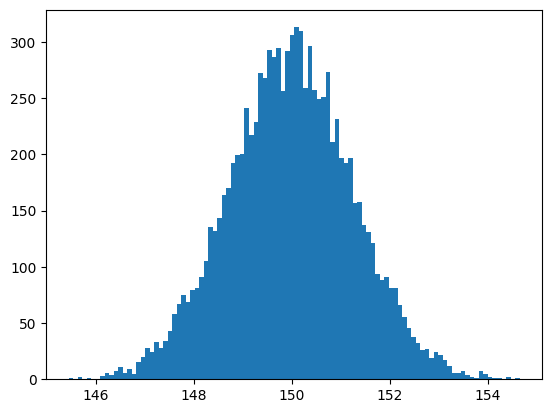

In [3]:
data = normalRandomGenerator(numberSamples=512,lowLim=100,highLim=200)
print("mean =",mean(data))
print("standard deviation =",stdev(data))

#Create a Figure object containing an Axes object into which we can
#plot a histogram.
fig,ax = plt.subplots(1,1)
print("type of fig =",fig)
print("type of ax =",ax)

#Plot and display the histogram with 100 bins.
ax.hist(data,bins=100)
#Write an output image file that cointains the histogram.
plt.savefig("StatisticsPart01.01.png")
plt.show()


**Description of the image shown above, StatisticsPart01.01.png**

**Type of image:** Histogram showing the distribution of a numerical variable.

**Overall summary:** The figure displays a histogram with a bell-shaped pattern, illustrating how the values of a dataset are distributed around a central point. The distribution appears symmetric, with most observations concentrated near the middle of the range.

**Detailed description:** The histogram consists of vertical bars representing frequency counts across evenly spaced bins. The x-axis spans values from approximately 145 to 155, and the y-axis ranges from 0 to slightly above 300. The tallest bars are centered near the value 150, indicating that this region contains the highest concentration of data points. Bar heights decrease gradually on both sides of the center, forming a smooth, rounded shape characteristic of a normal distribution. The bars are filled with a medium blue color, and the background is plain white. No annotations, gridlines, or additional markings are present.

**Purpose of the image:** This figure illustrates how a histogram can be used to visualize the distribution of a continuous variable in a Data Science context. It helps readers understand concepts such as central tendency, spread, and the visual characteristics of a normal distribution.

### Least mean square best fit line

The following function will compute a least mean square best fit line for a scatter plot. Click [here](https://www.varsitytutors.com/hotmath/hotmath_help/topics/line-of-best-fit) to view the source of the algorithm.

In [4]:
def lmsBestFitLine(xDataIn,yDataIn):
    xBar = sum(xDataIn)/len(xDataIn)
    yBar = sum(yDataIn)/len(yDataIn)

    numerator = 0
    for cnt in range(len(xDataIn)):
        numerator += (xDataIn[cnt] - xBar) * (yDataIn[cnt] - yBar)

    denominator = 0
    for cnt in range(len(xDataIn)):
        denominator += (xDataIn[cnt] -xBar)**2

    m = numerator/denominator

    b = yBar - m*xBar
    
    return (m,b)#slope,y-intercept

### Plot it

Test the function named lmsBestFitLine by drawing a best fit line on a scatter plot of negatively correlated data. 

*A correlation is a single numerical value that describes a relationship between two things, or variables.* 

*In a positive correlation, both variables move in the same direction. In other words, as one variable increases, so does the other.*  

*When two variables have a negative correlation, they have an inverse relationship.*

Note that this code calls the [numpy.arange](https://docs.scipy.org/doc/numpy/reference/generated/numpy.arange.html#numpy.arange) method from the numpy library to create a [numpy.ndarray](https://docs.scipy.org/doc/numpy/reference/generated/numpy.ndarray.html#numpy.ndarray) object containing 20 uniformly spaced values  ranging from 0 to 9.5

type of x = <class 'numpy.ndarray'>
type of y = <class 'list'>


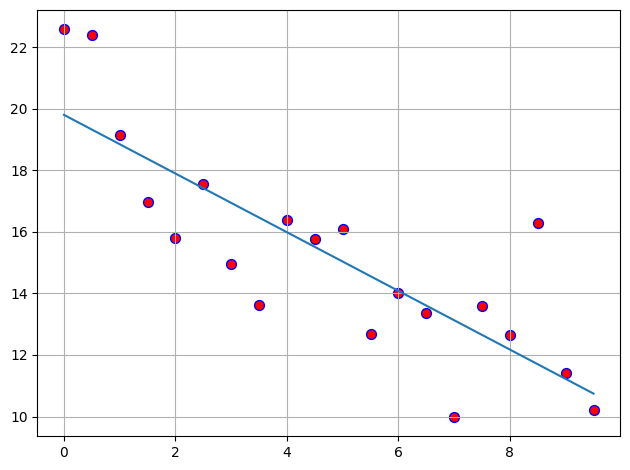

In [5]:
fig,ax1 = plt.subplots(1,1)

#Create some data with a negative correlation
random.seed(1)
x = np.arange(0,10,0.5)
y = []

print("type of x =",type(x))
print("type of y =",type(y))

for val in x:
    y.append(20 - val + random.gauss(0,2))

#Plot the data in a scatter plot
ax1.scatter(x,y,c='red',s=50,edgecolor='blue')

#Compute the best fit line
m,b =lmsBestFitLine(x,y)

#Draw a best fit line on the scatter plot
x1 = min(x)
y1 = m*x1 + b
x2 = max(x)
y2 = m*x2 + b
ax1.plot([x1,x2], [y1,y2])

plt.tight_layout()
plt.grid(True)
#Write an output image file that cointains the histogram.
plt.savefig("StatisticsPart01.02.png")
plt.show()

**Description of the image shown above, StatisticsPart01.02.png**

**Type of image:** Scatter plot with a fitted regression line.

**Overall summary:** The figure displays a set of data points along with a straight regression line that slopes downward, illustrating a negative relationship between the two variables. The plot highlights how the fitted line summarizes the overall trend in the data.

**Detailed description:** The scatter plot contains individual points drawn as red circles with blue edges. These points are distributed across an x-axis ranging from 0 to 9 and a y-axis ranging from 10 to 23. The fitted regression line extends diagonally from the upper left toward the lower right, indicating a decreasing linear trend. The background is plain white, and the axes are unlabeled. No annotations, gridlines, or additional markings appear in the figure.

**Purpose of the image:** This figure demonstrates how scatter plots and regression lines are used in Data Science to visualize relationships between two numerical variables. It helps readers understand how linear models capture overall trends even when individual data points vary around the fitted line.

## Basic statistical measurements

The basic staistical measurements are:
- mean, often represented by the greek letter mu (µ) or by xBar (${\bar {x}}$)
- standard deviation, often represented by the lower-case greek letter sigma (σ)
- median, middle value of the dataset
- mode, value that occurs most frequently in the dataset

It should come as no surprise that Python provides methods to compute and return all of these measurements on a dataset. The use of those methods will be illustrated in the code that follows.

### Skew

A left-skewed distribution has a long left tail. Left-skewed distributions are also called negatively-skewed distributions. That’s because there is a long tail in the negative direction on the number line. The mean is usually to the left of the peak.

A right-skewed distribution has a long right tail. Right-skewed distributions are also called positive-skew distributions. That’s because there is a long tail in the positive direction on the number line. The mean is usually to the right of the peak.

The normal distribution is a symmetric distribution with no skew. In the ideal case, the tails are exactly the same.

See [Statistics How To](http://www.statisticshowto.com/probability-and-statistics/skewed-distribution/).

### Median

The median is the middle value in a dataset, or the average of the two middle values if the number of values is even. If the distribuion is normal, the mean and the median are the same. However, that is not necessarily true if the distribution is not normal. 

The following code finds and displays the median two different ways. It also displays histograms of the datasets. 

The results illustrate the difference between the median and the mean for non-normal datasets. The results also illustrate that the **median may be a better indicator of the center of the distribution** than the mean in the presence of significant outliers.

***Note: If you copy and run this code, or any of the other code that creates two or more output plots under the Python interpreter, you will probably need to dismiss each plot from the screen before the next plot will appear.***

First handle the case with an even number of samples
Plot a histogram of the data with an even number of samples
data length = 8
median the hard way = 2.5
median the easy way = 2.5
xBar = -0.125
Dismiss the plot to continue


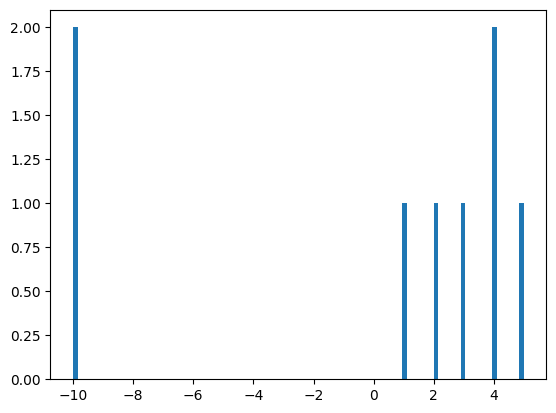

In [6]:
#Create a dataset with a skewed distribution and a significant outliers.
print("First handle the case with an even number of samples")
data = [-10,-10,1,2,3,4,4,5]

print("Plot a histogram of the data with an even number of samples")

fig,ax = plt.subplots(1,1)
ax.hist(data,bins=100)


#Compute the median the hard way
hardMedian = 0
data.sort()
if len(data)%2 == 0:
    #Even
    hardMedian = (data[len(data)//2] + data[len(data)//2 - 1])/2
else:
    #Odd
    hardMedian = data[len(data)//2]
print("data length =",len(data))
print("median the hard way =",hardMedian)
print("median the easy way =",median(data))
print("xBar =",mean(data))
print("Dismiss the plot to continue")
plt.savefig("StatisticsPart01.03.png")
plt.show()

**Description of the image shown above, StatisticsPart01.03.png**

**Type of image:** Bar chart showing the heights of individual bars at specific x-values.

**Overall summary:** The figure displays a set of vertical bars positioned at several distinct x-values, illustrating how the data values vary across those positions. The chart highlights both a prominent bar on the far left and a second tall bar near the right side of the plot.

**Detailed description:** The bar chart contains six vertical bars placed at x-values of approximately -10, 1, 2, 3, 4, and 5. The bar at x = -10 is the tallest, reaching a height of 2. The bars at x = 1, 2, 3, and 5 each have a height of 1. The bar at x = 4 has a height of 2, matching the height of the bar at x = -10. The x-axis ranges from roughly -10 to 5, and the y-axis ranges from 0 to 2. All bars are drawn in a uniform medium blue color against a plain white background. The axes are unlabeled, and there are no annotations, gridlines, or additional markings.

**Purpose of the image:** This figure illustrates how bar charts can represent discrete data values at specific positions along the x-axis. It helps readers understand how bar height conveys magnitude and how unusual values, such as a tall bar far from the others, can indicate potential outliers or asymmetries in a dataset.


Create another dataset with a skewed distribution
and an odd number of samples
Plot a histogram of the data with an odd number of samples
data length = 5
median the hard way = 3
median the easy way = 3
xBar = 2.8


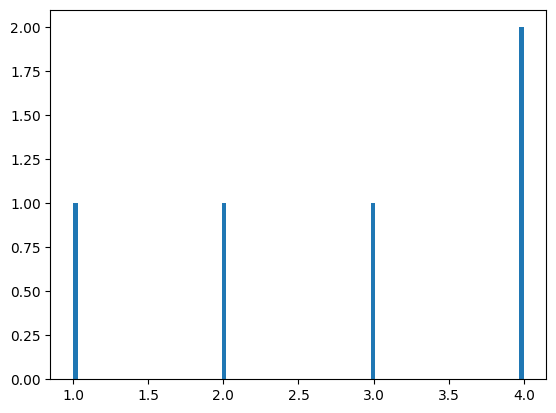

In [7]:
print()
print("Create another dataset with a skewed distribution")
print("and an odd number of samples")
data = [1,2,3,4,4]

print("Plot a histogram of the data with an odd number of samples")
fig,ax = plt.subplots(1,1)
ax.hist(data,bins=100)

#Compute the median the hard way
hardMedian = 0
data.sort()
if len(data)%2 == 0:
    #Even
    hardMedian = (data[len(data)//2] + data[len(data)//2 - 1])/2
else:
    #Odd
    hardMedian = data[len(data)//2]
print("data length =",len(data))
print("median the hard way =",hardMedian)
print("median the easy way =",median(data))
print("xBar =",mean(data))
plt.savefig("StatisticsPart01.04.png")
plt.show()

**Description of the image shown above, StatisticsPart01.04.png**

**Type of image:** Bar chart showing discrete values at four x-positions.

**Overall summary:** The figure presents four vertical bars that compare the heights of values at x = 1, 2, 3, and 4. The first three bars share the same height, while the fourth bar is noticeably taller.

**Detailed description:** The bar chart contains four vertical bars positioned at x-values 1, 2, 3, and 4. The bars at x = 1, 2, and 3 each have a height of 1. The bar at x = 4 has a height of 2, making it the tallest in the figure. All bars are drawn in a uniform medium blue color against a plain white background. The x-axis ranges from slightly below 1 to slightly above 4, and the y-axis ranges from 0 to 2. The axes are unlabeled, and the figure contains no annotations, gridlines, or additional markings.

**Purpose of the image:** This figure demonstrates how bar charts can be used to compare discrete values across categories. It helps readers see how differences in bar height reflect differences in magnitude, with the taller bar at x = 4 indicating a larger value than the others.

### Mean

The mean is the average of the values in a sample. The mathematical equation for the mean is:

${\displaystyle {\bar {x}}={\frac {1}{n}}\left(\sum _{i=1}^{n}{x_{i}}\right)={\frac {x_{1}+x_{2}+\cdots +x_{n}}{n}}}$

In case you aren't familiar with formulas like this, the Greek letter Σ means sum or summation. Briefly, this equation means that the mean is equal to the sum of all the values in a dataset divided by the number of values in the dataset.

The following code computes the mean of a dataset using three different approaches. Obviously all three approaches produce the same result. The mean value doesn't depend on the method used to compute it.

Then the code plots a histogram for the dataset. Because the distribution of this dataset tends towards normal, the mean should be near the center of the histogram.

mean from approach #1 = 149.9838921203297
mean from approach #2 = 149.98389212033013
mean from approach #3 = 149.98389212033013


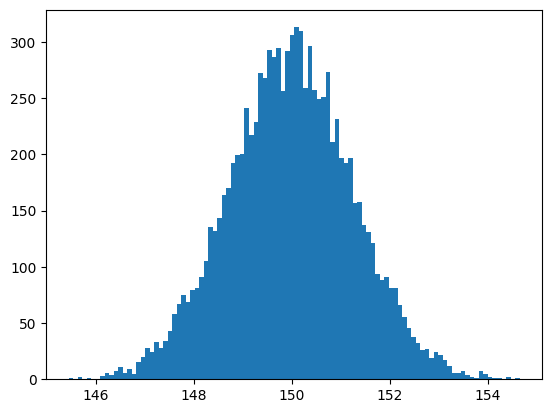

In [8]:
#Create a dataset
data = normalRandomGenerator(numberSamples=512,lowLim=100,highLim=200)

#Approach #1, use a for loop
total = 0
for val in data:
    total += val
print("mean from approach #1 =",total/len(data))

#Approach #2, call the built-in sum function
#print(sum(data))
print("mean from approach #2 =",sum(data)/len(data))

#Approach #3, call the built-in mean function
print("mean from approach #3 =",mean(data))

fig,ax = plt.subplots(1,1)
ax.hist(data,bins=100)
plt.savefig("StatisticsPart01.05.png")
plt.show()

**Description of the image shown above, StatisticsPart01.05.png**

**Type of image:** Histogram showing the distribution of a continuous numerical variable.

**Overall summary:** The figure displays a histogram with a smooth, bell-shaped pattern, illustrating how the data values are concentrated near the center of the range. The distribution appears symmetric, with frequencies decreasing gradually as values move away from the middle.

**Detailed description:** The histogram consists of vertical bars representing frequency counts across evenly spaced bins. The x-axis spans values from approximately 145 to 155, and the y-axis ranges from 0 to slightly above 300. The tallest bars are centered near the value 150, forming the peak of the distribution. Bar heights decrease steadily on both sides of the center, creating a rounded shape characteristic of a normal distribution. The bars are filled with a medium blue color, and the background is plain white. The axes are unlabeled, and the figure contains no annotations, gridlines, or additional markings.

**Purpose of the image:** This figure illustrates how a histogram can be used to visualize the distribution of a dataset in a Data Science context. It helps readers understand concepts such as central tendency, spread, and the visual characteristics of a normal distribution, especially when discussing how the mean relates to the center of the data.

### Standard deviation

The mathematical equation for the standard deviation of a sample is:

${\displaystyle s={\sqrt {\frac {\sum _{i=1}^{N}(x_{i}-{\overline {x}})^{2}}{N-1}}}}$

In other words, this is the equation that you should use to compute the standard deviation of a sample that will be used to estimate the standard deviation of the population from which the sample was taken.

The mathematical equation for the standard deviation of a population is:

${\displaystyle S={\sqrt {\frac {\sum _{i=1}^{N}(x_{i}-{\overline {x}})^{2}}{N}}}}$

The Python function named **statistics.stdev** computes and returns the standard deviation for a sample.

The Python function named **statistics.pstdev** computes and returns the standard deviation for a population.

The difference between these two equations is known as Bessel's correction, and is important mainly for samples with a small number of values. As the number of values increases, the two expressions tend toward the same limit. For samples with 1000 samples or more, the difference between the two will typically be in the third or fourth decimal place. Therefore, most of the example code in these tutorials calls **statistics.stdev** without regard for whether the dataset is a population or a sample.

Computation of the standard deviation is more involved than computation of the mean. In fact, computation of the mean is part of the computation of the standard deviation. The following code walks through the computation one step at a time and displays the final results. The computations are performed in-place requiring only one list object.

The code also displays a histogram of an intermediate version of the data after the mean has been removed.

sample standard deviation the easy way =     1.264458435829135
population standard deviation the easy way = 1.2643952113266916
mean of modified data = 0.0
population standard deviation the hard way = 1.2643952113266914


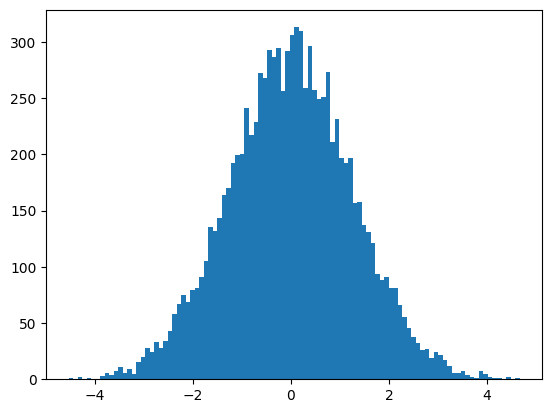

In [9]:
#Create a dataset with 10000 values and compute the mean
data = normalRandomGenerator(numberSamples=512,lowLim=100,highLim=200)
xBar = mean(data)

#Get the standard deviation for a sample the easy way.
print("sample standard deviation the easy way =    ",stdev(data))
#Get the standard deviation for a population the easy way.
print("population standard deviation the easy way =",pstdev(data))

#Subtract the mean from every value in the dataset.
for cnt in range(len(data)):
    data[cnt] -= xBar
    
#Display mean of modified data. Note that the mean is now zero.
print("mean of modified data =",mean(data)//1)
    
#Plot a histogram of the modified data but don't show it yet
fig,ax = plt.subplots(1,1)
ax.hist(data,bins=100)

    
#Square each value of the modified data.
for cnt in range(len(data)):
    data[cnt] = data[cnt]**2
    
#Compute the mean of the squared data
meanOfSquaredData = mean(data)

#Compute the square root
sigma = math.sqrt(meanOfSquaredData)

print("population standard deviation the hard way =",sigma)

#Now show the histogram
plt.savefig("StatisticsPart01.06.png")
plt.show()

**Description of the image shown above, StatisticsPart01.06.png**

**Type of image:** Histogram showing the distribution of a continuous numerical variable.

**Overall summary:** The figure presents a histogram with a bell-shaped pattern centered near zero, illustrating how values are distributed around the mean. The distribution appears symmetric, with frequencies decreasing as values move farther from the center.

**Detailed description:** The histogram is composed of many narrow vertical bars that represent frequency counts across closely spaced bins, suggesting a large sample size. The x-axis extends from approximately -4.5 on the left to about 4.5 on the right. The y-axis ranges from 0 at the bottom to slightly above 300 at the top. The tallest bars are located near the value 0 on the x-axis, forming the peak of the distribution. Bar heights decrease gradually and symmetrically on both sides of the center, creating a smooth, rounded shape typical of a normal distribution. All bars are filled with a medium blue color against a plain white background. The axes are unlabeled, and there are no annotations, gridlines, or additional markings.

**Purpose of the image:** This figure illustrates how a histogram can be used to visualize the distribution of data after a transformation that centers the values around zero. In the context of standard deviation, it helps readers see how deviations from the mean are spread across positive and negative values, reinforcing the idea of symmetry and dispersion in a normally distributed dataset.

### Mode

The mode is the value that occurs most often in a dataset. The following code calls the statistics.multimode method to find the mode of a dataset.

The following code displays proper behavior for two cases: one with a unique mode and one without a unique mode.

In [10]:
from statistics import multimode

def describe_mode(data):
    modes = multimode(data)

    if len(modes) == 0:
        print("The dataset has no mode.")
    elif len(modes) == 1:
        print("Unique mode =", modes[0])
    else:
        print("No unique mode. The dataset is multimodal.")
        print("Modes =", modes)

# Example dataset with a unique mode
print("Create a dataset that has a unique mode")
data = [1, 2, 3, 4, 4]
print("data:",data)

describe_mode(data)

Create a dataset that has a unique mode
data: [1, 2, 3, 4, 4]
Unique mode = 4


In [11]:
from statistics import multimode

def describe_mode(data):
    modes = multimode(data)

    if len(modes) == 0:
        print("The dataset has no mode.")
    elif len(modes) == 1:
        print("Unique mode =", modes[0])
    else:
        print("No unique mode. The dataset is multimodal.")
        print("Modes =", modes)

# Example dataset with no unique mode
print("Create a dataset that has no unique mode")
data = [1, 2, 2, 3, 4, 4]
print("data:",data)
describe_mode(data)

Create a dataset that has no unique mode
data: [1, 2, 2, 3, 4, 4]
No unique mode. The dataset is multimodal.
Modes = [2, 4]


## Sampling error

### Sampling error - part 1

*Definition: In statistics, [sampling error](https://en.wikipedia.org/wiki/Sampling_error) is the error caused by observing a sample instead of the whole population. The sampling error is the difference between a sample statistic used to estimate a population parameter and the actual but unknown value of the parameter. An estimate of a quantity of interest, such as an average or percentage, will generally be subject to sample-to-sample variation. These variations in the possible sample values of a statistic can theoretically be expressed as sampling errors, although in practice the exact sampling error is typically unknown. Sampling error also refers more broadly to this phenomenon of random sampling variation.*

The following code creates a reproducible population of 49,000 uniformly distributed values and computes the mean (mu) of the population.

A sample consisting of 1000 values is taken from the population. The mean of the sample (xBar) is used to estimate the mu of the population. The sampling error is computed as the difference between the two.

A histogram is also displayed for the population and for the sample.

Plot a histogram of the population
Dismiss the plot to continue


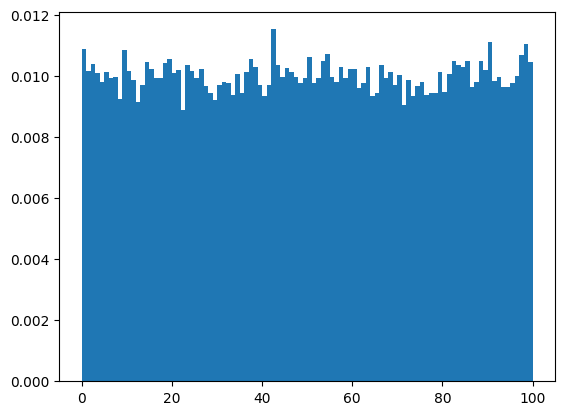

In [12]:
#Access the entire population
population = normalRandomGenerator(\
    seed=1,dataLength=49000,numberSamples=1,lowLim=0,highLim=100)
print("Plot a histogram of the population")
print("Dismiss the plot to continue")
fig,ax = plt.subplots(1,1)
ax.hist(population,bins=100,density=True)
plt.savefig("StatisticsPart01.08.png")
plt.show()

**Description of the image shown above, StatisticsPart01.08.png**

**Type of image:** Histogram showing the distribution of a continuous numerical variable for an entire population.

**Overall summary:** The figure presents a histogram with a flat, even pattern across the entire range of values, illustrating a uniformly distributed dataset. The bar heights remain relatively consistent from left to right, indicating that all values occur with roughly equal frequency.

**Detailed description:** The histogram consists of many narrow vertical bars that represent frequency densities across evenly spaced bins. The x-axis spans values from 0 to 100, and the y-axis ranges from 0.000 at the bottom to slightly above 0.012 at the top. The bars are drawn in a uniform medium blue color and are distributed evenly across the x-axis, with only small variations in height. This creates a level, rectangular appearance characteristic of a uniform distribution. The background is plain white, and the axes are unlabeled. No annotations, gridlines, or additional markings appear in the figure.

**Purpose of the image:** This figure demonstrates how a histogram can be used to visualize a uniformly distributed population in a Data Science context. It helps readers understand how uniform distributions differ from bell-shaped or skewed distributions and provides a visual foundation for discussing sampling error, population characteristics, and the behavior of sample statistics drawn from a uniform population.

mu = 50.016661856020214
xBar = 51.41370278623857

If xBar is used to estimate mu, the sampling error 
is the difference between the two.

sampling error = mu - xBar = -1.3970409302183526


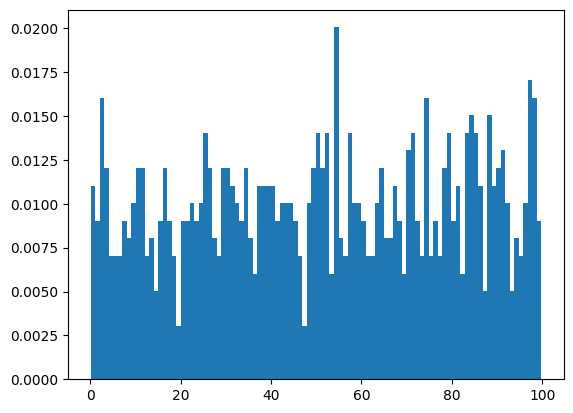

In [13]:
#Note that it is possible to compute the mu for the population and the sampling error later
#only because we have access to the entire population in this case.
mu = mean(population)
print("mu =",mu)

#Get a sample from the population
sample = normalRandomGenerator(\
    seed=1,dataLength=1000,numberSamples=1,lowLim=0,highLim=100)
#Plot a histogram of the sample
fig,ax = plt.subplots(1,1)
ax.hist(sample,bins=100,density=True)


xBar = mean(sample)
print("xBar =",xBar)

print()
print("If xBar is used to estimate mu, the sampling error \n\
is the difference between the two.")
print()
print("sampling error = mu - xBar =",mu - xBar)
plt.savefig("StatisticsPart01.09.png")
plt.show()

**Description of the image shown above, StatisticsPart01.09.png**

**Type of image:** Histogram showing the distribution of a continuous numerical variable that is a sample from the population shown earlier.

**Overall summary:** The figure displays a histogram with many narrow bars of varying height, illustrating how the values in a sample are distributed across a range of 100 bins. The pattern appears irregular, with bar heights fluctuating from left to right.

**Detailed description:** The histogram contains 100 vertical bars positioned along an x-axis that spans values from 0 to 100. The y-axis ranges from 0.0000 at the bottom to 0.0200 at the top. Each bar represents the density of values falling within its corresponding bin. The bars are drawn in a uniform medium blue color and vary in height, with some reaching close to 0.0200 while others are much shorter. The distribution does not form a smooth curve; instead, the bar heights rise and fall in a jagged pattern across the entire x-axis. The background is plain white, and the axes are unlabeled. No annotations, gridlines, or additional markings appear in the figure.

**Purpose of the image:** This figure illustrates how a histogram can be used to visualize the distribution of a sample drawn from a larger population. In the context of sampling error, it helps readers compare the characteristics of a sample distribution to those of the full population and understand how sample-to-sample variation affects estimates such as the mean.

### Sampling error - part 2

As above, the following code creates the same reproducible population of 49,000 uniformly distributed values and computes the mean (mu) of the population.

A sample consisting of 10,000 values (as opposed to 1000 values above) is taken from the population. The mean of the sample (xBar) is used to estimate the mu of the population. The sampling error is computed as the difference between the two. A factor of ten increase in the sample size resulted in a reduction of the sampling error by a factor of 6.5.

A histogram is also displayed for the population and for the sample.

Plot a histogram of the population
Dismiss the plot to continue


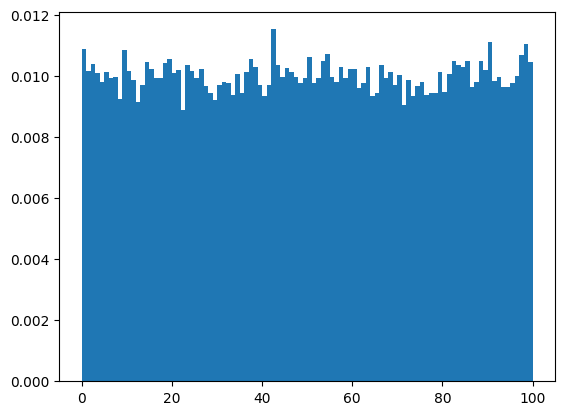

In [14]:
#Access the entire population
population = normalRandomGenerator(\
    seed=1,dataLength=49000,numberSamples=1,lowLim=0,highLim=100)
print("Plot a histogram of the population")
print("Dismiss the plot to continue")
fig,ax = plt.subplots(1,1)
ax.hist(population,bins=100,density=True)
plt.savefig("StatisticsPart01.10.png")
plt.show()

**Description of the image shown above, StatisticsPart01.10.png**

**Type of image:** Histogram showing the distribution of a continuous numerical variable for an entire population.

**Overall summary:** The figure displays a histogram with many narrow bars of similar height, illustrating a dataset whose values are spread evenly across the full range. The overall pattern is flat, indicating a uniform distribution.

**Detailed description:** The histogram contains 100 vertical bars arranged along an x-axis that spans values from 0 to 100. The y-axis ranges from 0.0000 at the bottom to 0.0120 at the top. Each bar is drawn in a medium blue color and represents the density of values within its corresponding bin. The bar heights vary only slightly from one bin to the next, producing a level appearance across the entire width of the plot. The background is plain white, and the axes are unlabeled. The figure contains no annotations, gridlines, or additional markings.

**Purpose of the image:** This figure demonstrates how a histogram can be used to visualize a uniformly distributed population in a Data Science context. It helps readers understand how uniform distributions differ from bell-shaped or skewed distributions and provides a visual foundation for discussing sampling error, population characteristics, and the behavior of sample statistics drawn from a uniform population.

mu = 50.016661856020214

If xBar is used to estimate mu, the sampling error 
is the difference between the two.

xBar = 49.801785158479724
sampling error = mu - xBar = 0.21487669754048966


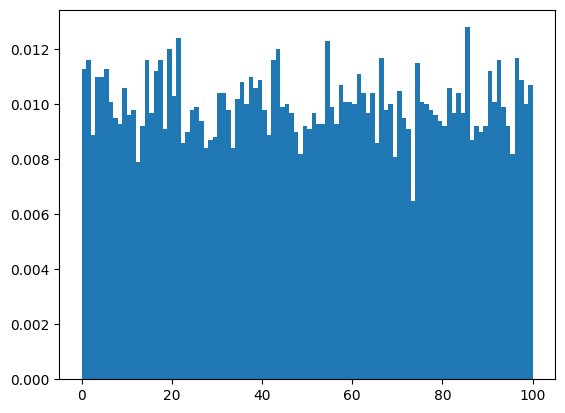

In [15]:
#Note that it is possible to compute the mu for the population and the sampling error later
#only because we have access to the entire population in this case.
mu = mean(population)
print("mu =",mu)

#Get a sample from the population
sample = normalRandomGenerator(\
    seed=1,dataLength=10000,numberSamples=1,lowLim=0,highLim=100)
#Plot a histogram of the sample
fig,ax = plt.subplots(1,1)
ax.hist(sample,bins=100,density=True)
print()
print("If xBar is used to estimate mu, the sampling error \n\
is the difference between the two.")
print()
xBar = mean(sample)
print("xBar =",xBar)
print("sampling error = mu - xBar =",mu - xBar)
plt.savefig("StatisticsPart01.11.png")
plt.show()


**Description of the image shown above, StatisticsPart01.11.png**

**Type of image:** Histogram showing the distribution of a continuous numerical variable for a sample of a population.

**Overall summary:** The figure presents a histogram with many narrow bars of similar height, illustrating how the values in a large sample are distributed across a uniform range. The overall pattern is relatively flat, indicating that the sample is drawn from a uniformly distributed population.

**Detailed description:** The histogram contains 100 vertical bars arranged along an x-axis that spans values from 0 to 100. The y-axis ranges from 0.0000 at the bottom to 0.0120 at the top. Each bar is drawn in a medium blue color and represents the density of values within its corresponding bin. The bar heights vary only slightly from one bin to the next, producing a mostly level appearance across the entire width of the plot. The background is plain white, and the axes are unlabeled. The figure contains no annotations, gridlines, or additional markings.

**Purpose of the image:** This figure illustrates how a histogram can be used to visualize the distribution of a large sample drawn from a uniformly distributed population. In the context of sampling error, it helps readers compare the characteristics of a large sample to those of the full population and understand how increasing the sample size reduces the variability of estimates such as the mean.

## Visualizing x-y relationships

### Visualizing x-y relationships part 1

The following code creates two sets of random data values, extracts the values in pairs and plots them on a scatter plot. Then it draws a best fit line through the plot.

There appears to be no obvious relationship between the two sets of data as should be the case because there is no relationship between the two sets of data.

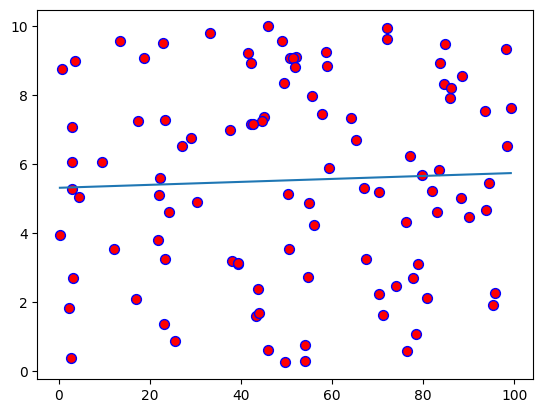

In [16]:
xData = normalRandomGenerator(\
    seed=1,dataLength=100,numberSamples=1,lowLim=0,highLim=100)
yData = normalRandomGenerator(\
    seed=2,dataLength=100,numberSamples=1,lowLim=0,highLim=10)

fig,(ax1) = plt.subplots(1,1)
ax1.scatter(xData,yData,c='red',s=50,edgecolor='blue')

#Compute and draw the best fit line
m,b =lmsBestFitLine(xData,yData)

#Draw a best fit line
x1 = min(xData)
y1 = m*x1 + b
x2 = max(xData)
y2 = m*x2 + b
ax1.plot([x1,x2], [y1,y2])
plt.savefig("StatisticsPart01.12.png")
plt.show()

**Description of the image shown above, StatisticsPart01.12.png**

**Type of image:** Scatter plot with a fitted regression line.

**Overall summary:** The figure displays a cloud of data points scattered across the plot, along with a straight best‑fit line. The line slopes gently upward, indicating a very weak positive relationship between the two variables.

**Detailed description:** The scatter plot contains many individual points drawn as red circles with blue outlines. These points are distributed across an x‑axis ranging from 0 to 100 and a y‑axis ranging from 0 to 10. The points appear widely dispersed, with no clear clustering or strong directional pattern. A blue regression line runs diagonally from the lower left toward the upper right, showing a very slight upward trend. The background is plain white, and the axes are unlabeled. The figure includes no annotations, gridlines, or additional markings.

**Purpose of the image:** This figure illustrates how scatter plots and regression lines can be used to explore potential relationships between two numerical variables. In this example, the weak upward slope of the fitted line helps readers see that the two datasets have little meaningful correlation, which is expected when the paired values are generated independently.

### Visualizing x-y relationships part 2

The following code creates the same two sets of random data values, sorts each set, extracts the values in pairs and plots them on a scatter plot. Then it draws a best fit line through the plot.

There appears to be a causal relationship between the two sets of data but it would be incorrect to draw that conclusion. The two sets of data continue to be unrelated. The appearance of a causal relationship resulted simply from sorting the data. ***Correlation does not imply causation***.

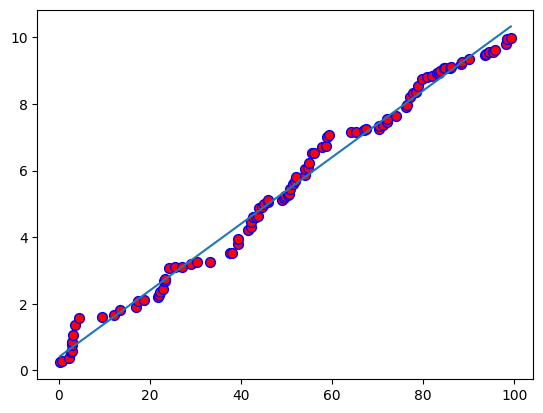

In [17]:
xData = normalRandomGenerator(\
    seed=1,dataLength=100,numberSamples=1,lowLim=0,highLim=100)
yData = normalRandomGenerator(\
    seed=2,dataLength=100,numberSamples=1,lowLim=0,highLim=10)

xData.sort()
yData.sort()

fig,(ax1) = plt.subplots(1,1)
ax1.scatter(xData,yData,c='red',s=50,edgecolor='blue')

#Compute and draw the best fit line
m,b =lmsBestFitLine(xData,yData)

#Draw a best fit line
x1 = min(xData)
y1 = m*x1 + b
x2 = max(xData)
y2 = m*x2 + b
ax1.plot([x1,x2], [y1,y2])
plt.savefig("StatisticsPart01.13.png")
plt.show()

**Description of the image shown above, StatisticsPart01.13.png**

**Type of image:** Scatter plot with a fitted curve.

**Overall summary:** The figure shows a set of data points arranged in an upward‑curving pattern, along with a smooth fitted line that captures the overall trend. The visual impression suggests a strong relationship between the two variables, even though the underlying data is unrelated.

**Detailed description:** The scatter plot contains many individual points drawn as red circles with blue outlines. The x‑axis ranges from 0 to 100, and the y‑axis ranges from 0 to 10. Unlike a random cloud of points, the values form a rising pattern: the points appear loosely aligned along a curve that increases more rapidly as x increases. A smooth blue fitted line follows this curved shape, reinforcing the appearance of a nonlinear upward trend. The background is plain white, and the axes are unlabeled. The figure includes no annotations, gridlines, or additional markings.

**Purpose of the image:** This figure demonstrates how sorting two independent datasets before pairing their values can create the illusion of a meaningful relationship. It helps readers understand that visual patterns can be misleading and reinforces the principle that correlation—especially one produced artificially—does not imply causation.

### Visualizing x-y relationships part 3

The following code creates the same two sets of random data values, but the two set of data are used differently than above.

As above, one set of random data is used as the x values for a scatter plot. Each y value for the scatter plot was created as one-tenth the value of the corresponding x value plus a noise value from the second set of random data values. After plotting the x and y values on the scatter plot, the code draws a best fit line through the plot.

There appears to be a causal relationship between the two sets of data. In this case, it would be correct to draw that conclusion. The two sets of data are definitely related, having been created from the same set of random data.

The bottom line is that an apparent correlation between two datasets on a scatter plot may or may not indicate causation. You need to know a lot about the origins of the data before drawing conclusions on causation. Otherwise, [lurking variables](http://study.com/academy/lesson/lurking-variable-in-statistics-definition-example.html) may cause you to draw invalid conclusions. ***Correlation does not imply causation***.

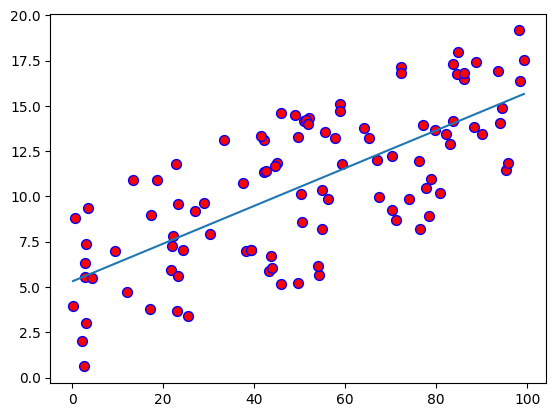

In [18]:
xData = normalRandomGenerator(\
    seed=1,dataLength=100,numberSamples=1,lowLim=0,highLim=100)
noise = normalRandomGenerator(\
    seed=2,dataLength=100,numberSamples=1,lowLim=0,highLim=10)

yData = []
for cnt in range(len(xData)):
    yData.append(xData[cnt]/10 + noise[cnt])

fig,(ax1) = plt.subplots(1,1)
ax1.scatter(xData,yData,c='red',s=50,edgecolor='blue')

#Compute and draw the best fit line
m,b =lmsBestFitLine(xData,yData)

#Draw a best fit line
x1 = min(xData)
y1 = m*x1 + b
x2 = max(xData)
y2 = m*x2 + b
ax1.plot([x1,x2], [y1,y2])
plt.savefig("StatisticsPart01.14.png")
plt.show()

**Description of the image shown above, StatisticsPart01.14.png**

**Type of image:** Scatter plot with a fitted regression line.

**Overall summary:** The figure shows a set of data points arranged in a generally upward‑sloping pattern, along with a straight regression line that captures the positive relationship between the variables. The visual impression suggests a clear linear association between x and y.

**Detailed description:** The scatter plot contains many individual points drawn as red circles with blue outlines. These points are distributed across an x‑axis ranging from 0 to 100 and a y‑axis ranging from 0 to 20. The points form a loose but noticeable upward trend: as x increases, the corresponding y values tend to increase as well. A blue regression line runs diagonally from the lower left to the upper right, reinforcing the appearance of a positive linear relationship. The background is plain white, and the axes are unlabeled. The figure includes no annotations, gridlines, or additional markings.

**Purpose of the image:** This figure illustrates how scatter plots and regression lines can reveal genuine relationships between two numerical variables. In this example, the y values were constructed directly from the x values with added noise, so the positive trend reflects a true causal connection. The image supports the broader lesson that while correlation may or may not imply causation, understanding how the data was generated is essential before drawing conclusions.

## Visualizing student data

The following example is based on a sample of 50 students taken from the entire population of students enrolled in an online statistics course.

### A histogram with four bins

The following code shows a non-normalized histogram of the data with four bins. 

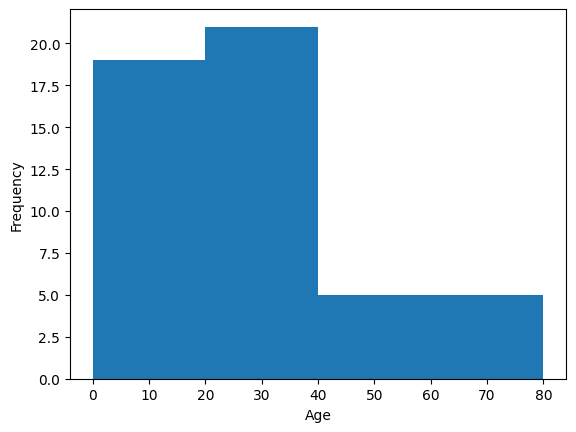

In [19]:
sample =[15,19,18,14,13,27,16,65,15,31,22,15,24,22,51,24,20,45,22,33,24,27,18,66,15,18,\
         39,10,30,13,19,28,53,28,65,30,20,21,20,18,20,23,18,41,52,75,19,63,14,18]

fig,ax = plt.subplots(1,1)
ax.hist(sample,bins=4,range=(0,80))

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig("StatisticsPart01.15.png")
plt.show()

**Description of the image shown above, StatisticsPart01.15**

**Type of image:** Histogram showing the distribution of a continuous numerical variable.

**Overall summary:** The figure presents a histogram with four wide bars that display how values are distributed across an age range from 0 to 80. The tallest bars occur in the lower and middle portions of the range, indicating that most values fall below age 40.

**Detailed description:** The histogram contains four vertical bars of equal width, each representing one of the four bins spanning the full age range. The first bin covers ages 0 to 20 and reaches a height of roughly 19 on the frequency scale. The second bin spans ages 20 to 40 and is the tallest, with a height of approximately 21. The third bin covers ages 40 to 60 and is noticeably shorter, with a height of about 5. The fourth bin spans ages 60 to 80 and rises to a moderate height of roughly 5 as well. All bars are drawn in a uniform medium blue color. The x‑axis is labeled “Age,” and the y‑axis is labeled “Frequency.” The background is plain white, and the figure contains no annotations, gridlines, or additional markings.

**Purpose of the image:** This figure illustrates how a non‑normalized histogram with four bins can be used to visualize the distribution of ages in a sample of students. It helps readers see how the sample is concentrated in certain age ranges and provides a foundation for discussing sampling, binning choices, and interpretation of frequency‑based histograms.



### A normalized histogram with 20 bins

The following code shows a normalized histogram for the same sample with 20 bins showing more detail than the histogram above. The distribution is positively skewed. The code also displays the median, mean, standard deviation, and mode for the sample.

sample median = 22.0
sample mean = 28.32
sample standard deviation = 16.46200325052842
sample mode = 18


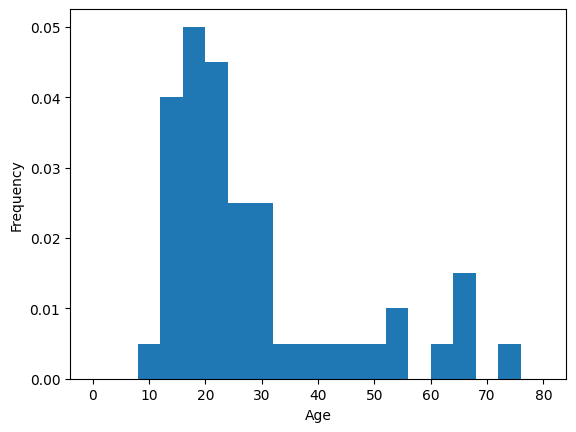

In [20]:
sample =[15,19,18,14,13,27,16,65,15,31,22,15,24,22,51,24,20,45,22,33,24,27,18,66,15,18,\
         39,10,30,13,19,28,53,28,65,30,20,21,20,18,20,23,18,41,52,75,19,63,14,18]

print("sample median =",median(sample))
print("sample mean =",mean(sample))
print("sample standard deviation =",stdev(sample))
print("sample mode =",mode(sample))

fig,ax = plt.subplots(1,1)
ax.hist(sample,bins=20,range=(0,80),density=True)

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig("StatisticsPart01.16.png")
plt.show()

**Description of the image shown above, StatisticsPart01.16.png**

**Type of image:** Normalized histogram showing the distribution of a continuous numerical variable.

**Overall summary:** The figure presents a histogram with many narrow bars that display how values are distributed across an age range from 0 to 80. The bars vary in height, with the tallest bars occurring near the lower end of the range, indicating that the distribution is positively skewed.

**Detailed description:** The histogram contains 20 vertical bars of equal width, each representing one of the bins spanning the full age range. The x‑axis is labeled “Age,” and the y‑axis is labeled “Frequency.” The tallest bars appear between ages roughly 15 and 25, forming a noticeable peak. Bar heights gradually decrease as the age values increase, with smaller bars appearing in the higher age ranges. The bars are drawn in a uniform medium blue color against a plain white background. No annotations, gridlines, or additional markings appear in the figure.

**Purpose of the image:** This figure illustrates how a normalized histogram with 20 bins can reveal finer details in the distribution of a dataset. In this example, the histogram highlights the positive skew of the age distribution and supports the accompanying statistical summary, which includes the median, mean, standard deviation, and mode for the sample.

--To be continued in the tutorial titled Statistics Exercises Part 2--

Author:
Prof. Richard G. Baldwin, Austin Community College, Austin, TX

File: StatisticsPart01.ipynb

Revised: 02/22/26

Copyright 2018 Richard G. Baldwin

-end-